# Data Exploration



**Install libraries**

In [27]:
%pip install matplotlib
%pip install scikit-learn
%pip install xgboost
%pip install scipy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


**Import libraries**

In [28]:
import pandas as pd # should already be installed on data_preprocess.ipynb
import matplotlib.pyplot as plt
import os
import datetime
from scipy.interpolate import make_interp_spline
import numpy as np

## Load data

Loading the data from the processed CSV file created in data_preprocess.ipynb

In [29]:
working_dir = os.getcwd()
order_forms_processed_dir = os.path.join(working_dir, "order_forms_processed")

df = pd.read_csv(os.path.join(order_forms_processed_dir, "order_forms_sorted.csv"))
df["Timestamp"] = pd.to_datetime(df["Timestamp"], utc=True)
df["Timestamp"] = df["Timestamp"].dt.tz_convert('US/Pacific') # convert to Pacific time
df.head()


,Unnamed: 0,Timestamp,TEA,FLAVOR,MILK,ICE [Ice Level],SWEETNESS [Sweetness Level],Toppings,NAME,Started,Completed,Form_ID
0,0,2022-10-20 19:02:40-07:00,THAI,NaN,MILK,50%,75%,BOBA,res - coop,TRUE,TRUE,10/14/2022 16:49:26
1,1,2022-10-20 19:05:44-07:00,SPECIAL,NaN,NaN,NaN,NaN,BOBA,sean,TRUE,TRUE,10/14/2022 16:49:26
2,2,2022-10-20 19:06:32-07:00,JSMN,NaN,MILK,50%,75%,LYCHEE,helin,TRUE,TRUE,10/14/2022 16:49:26
3,3,2022-10-20 19:07:23-07:00,SPECIAL,NaN,NaN,NaN,NaN,NaN,katie,TRUE,TRUE,10/14/2022 16:49:26
4,4,2022-10-20 19:08:09-07:00,TARO,NaN,Soy,NaN,100%,BOBA,andrea,TRUE,TRUE,10/14/2022 16:49:26


## Time Series Analysis
First, I'm curious about how the shape of orders changes from semester to semester. First, let's add semester data to the dataframe and look at the number of orders by school year and semester.

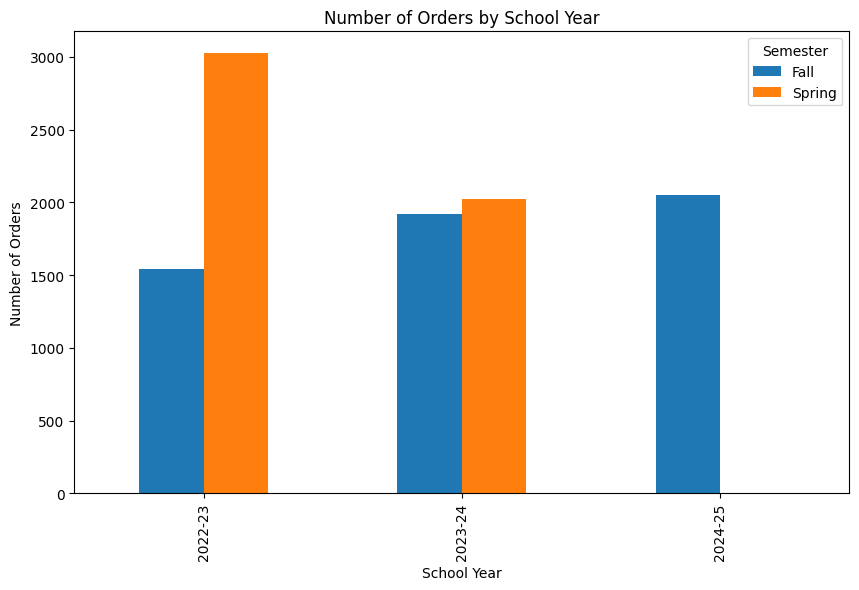

In [30]:
semesters_dict = {
    "Fall": "9-01",
    "Spring": "1-01",
}

df["Year"] = df["Timestamp"].dt.year
df["Month"] = df["Timestamp"].dt.month
df["Day"] = df["Timestamp"].dt.day
df["Semester"] = df["Timestamp"].dt.month.apply(lambda x: "Fall" if x in [9, 10, 11, 12] else "Spring")

df["School_Year"] = df.apply(lambda x: 
    f"{x['Year']-1}-{str(x['Year'])[2:]}" if x["Semester"] == "Spring"
    else f"{x['Year']}-{str(x['Year']+1)[2:]}", 
    axis=1
)

# plot with school years
order = ["Fall", "Spring"]
df.groupby(["School_Year", "Semester"]).size().unstack()[order].plot(kind="bar", figsize=(10, 6))
plt.title("Number of Orders by School Year")
plt.xlabel("School Year")
plt.ylabel("Number of Orders")
plt.show()

I want to visualize the shape of orders for each semester, so I need to add a column for the week of the semester that each order was placed.

In [31]:
df["Weekday"] = df["Timestamp"].dt.day_name()
first_monday_of_semester_dict = {
    "Fall_2022": "2022-08-29",
    "Spring_2023": "2023-01-16",
    "Fall_2023": "2023-08-28",
    "Spring_2024": "2024-01-15",
    "Fall_2024": "2024-08-26",
    "Spring_2025": "2025-01-20",
}

def calculate_school_week(timestamp, semester, year, first_monday_dict):
    """calculate week number relative to first monday of the semester
    
    args:
        timestamp: datetime object
        semester: "Fall" or "Spring"
        school_year: string like "2022-23"
        first_monday_dict: dictionary mapping semester (e.g., "Fall_2022") to first monday of semester
    
    returns:
        int: week number (Spring semester weeksare offset by +30)
    """
    if semester not in ["Fall", "Spring"]:
        return 0
    
    # get first monday of the semester
    semester_key = f"{semester}_{year}"
    first_monday = datetime.datetime.strptime(first_monday_dict[semester_key], "%Y-%m-%d")
    
    # calculate week difference
    week_num = timestamp.isocalendar().week - first_monday.isocalendar().week
        
    return week_num

df["School_Week"] = df.apply(lambda x: calculate_school_week(
    x["Timestamp"], 
    x["Semester"], 
    x["Year"], 
    first_monday_of_semester_dict
), axis=1)


Ok! Now I can visualize the shape of orders for each semester with weeks on the x-axis and the number of orders on the y-axis.

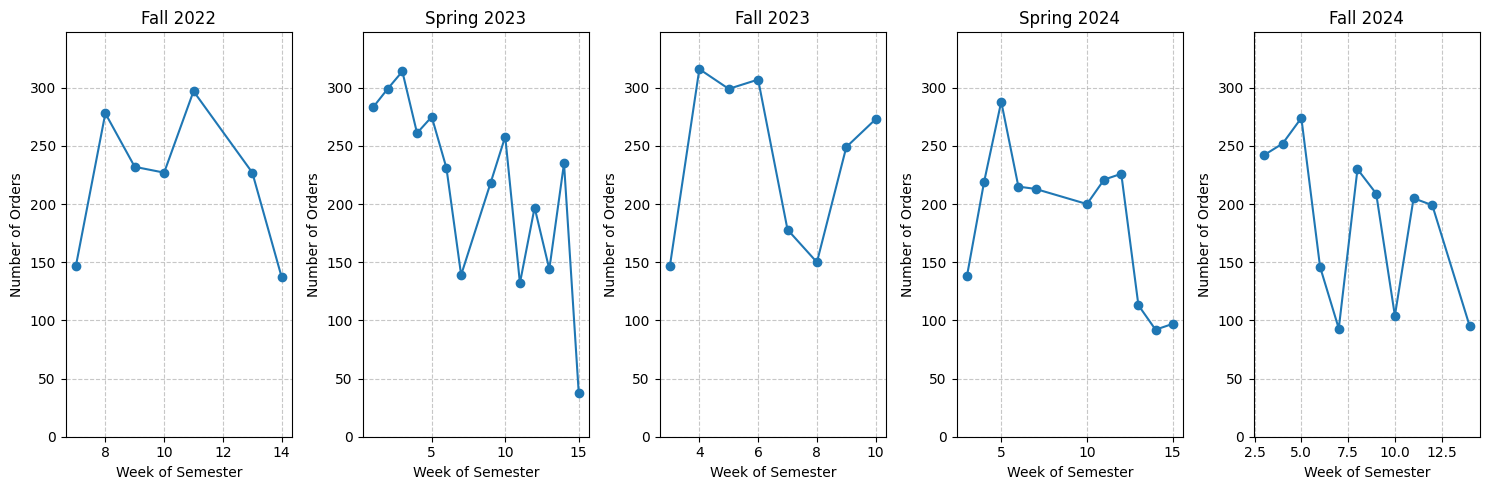

In [32]:
# calculate number of rows and columns needed for subplots
n_cols = 5  # can adjust later
n_rows = (len(order) + n_cols - 1) // n_cols 

# create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()  # flatten to make indexing easier

plot_idx = 0
order = ["Fall 2022", "Spring 2023", "Fall 2023", "Spring 2024", "Fall 2024", "Spring 2025"]

for semester_label in order:
    # parse year and semester from label
    sem, year = semester_label.split()
    year = int(year)
    
    # get data for this semester
    semester_data = df[
        (df["Year"] == year) & 
        (df["Semester"] == sem)
    ]
    
    if len(semester_data) > 0:
        # count orders per week
        weekly_orders = semester_data.groupby("School_Week").size()
        
        # plot line on appropriate subplot
        axes[plot_idx].plot(weekly_orders.index, weekly_orders.values, marker='o')
        axes[plot_idx].set_title(semester_label)
        axes[plot_idx].set_xlabel("Week of Semester")
        axes[plot_idx].set_ylabel("Number of Orders")
        axes[plot_idx].grid(True, linestyle='--', alpha=0.7)
        
        plot_idx += 1

# remove empty subplots if any
for idx in range(plot_idx, len(axes)):
    fig.delaxes(axes[idx])

# align y-axis limits
y_max = df.groupby(["Year", "Semester", "School_Week"]).size().max() * 1.1
for ax in axes[:plot_idx]:
    ax.set_ylim(0, y_max)
    
plt.tight_layout()
plt.show()

Interesting, each semester seems to have a ramp up period in the first few weeks and a wind down at the end, but this could be due to the fact that we're usually only open for one day the first week we're open each semester. I'm going to remove orders that aren't placed on Tuesday or Thursday just to standardize the data, then 

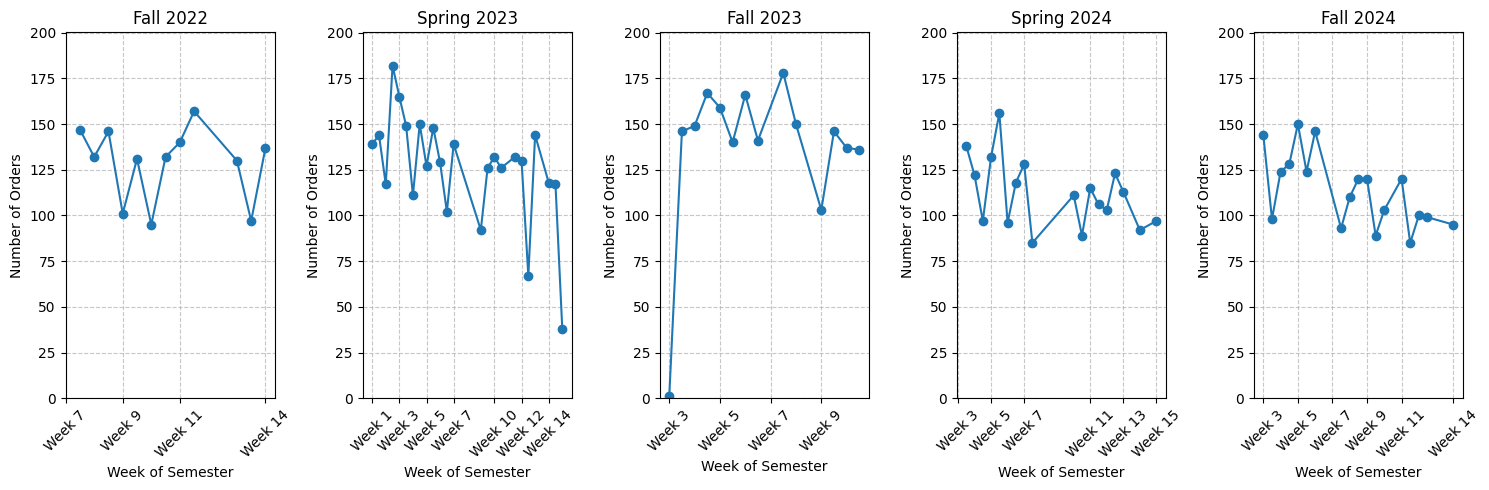

In [33]:
# create offset dictionary for each day
offset_dict = {
    "Tuesday": 0,
    "Thursday": 0.5,
}

# create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()  # flatten to make indexing easier

plot_idx = 0

for semester_label in order:
    # parse year and semester from label
    sem, year = semester_label.split()
    year = int(year)
    
    # get data for this semester
    semester_data = df[
        (df["Year"] == year) & 
        (df["Semester"] == sem)
    ]
    
    if len(semester_data) > 0:
        # count orders per week-day combination
        weekly_orders = semester_data.groupby(["School_Week", "Weekday"]).size().reset_index()
        
        # add offset based on weekday
        weekly_orders["Week_Offset"] = weekly_orders["School_Week"] + weekly_orders["Weekday"].map(offset_dict)
        weekly_orders.sort_values(by="Week_Offset", inplace=True)
        
        # plot line on appropriate subplot
        axes[plot_idx].plot(weekly_orders["Week_Offset"], weekly_orders[0], marker='o')
        axes[plot_idx].set_title(semester_label)
        axes[plot_idx].set_xlabel("Week of Semester")
        axes[plot_idx].set_ylabel("Number of Orders")
        axes[plot_idx].grid(True, linestyle='--', alpha=0.7)
        
        # Show every second
        weeks = weekly_orders["School_Week"].unique()
        tick_weeks = weeks[::2]  # step by 2
        axes[plot_idx].set_xticks(tick_weeks)
        axes[plot_idx].set_xticklabels([f"Week {w}" for w in tick_weeks])
        axes[plot_idx].tick_params(axis='x', rotation=45)
        
        plot_idx += 1

# remove empty subplots
for idx in range(plot_idx, len(axes)):
    fig.delaxes(axes[idx])

# align y-axis limits
y_max = df.groupby(["Year", "Semester", "School_Week", "Weekday"]).size().max() * 1.1
for ax in axes[:plot_idx]:
    ax.set_ylim(0, y_max)
    
plt.tight_layout()

# save to file
if not os.path.exists("figures"):
    os.makedirs("figures")

plt.savefig(
    os.path.join("figures", "order_volume_by_semester.png"),
    dpi=300,
    bbox_inches='tight',
    facecolor='white',
    pad_inches=0.1
)

# then show and close
plt.show()
plt.close()

I'm wondering if we can adjust the y-axis to accound for days that we're not open the entire 2.5 hours, and what that would look like.

Great! Lets make it prettier.

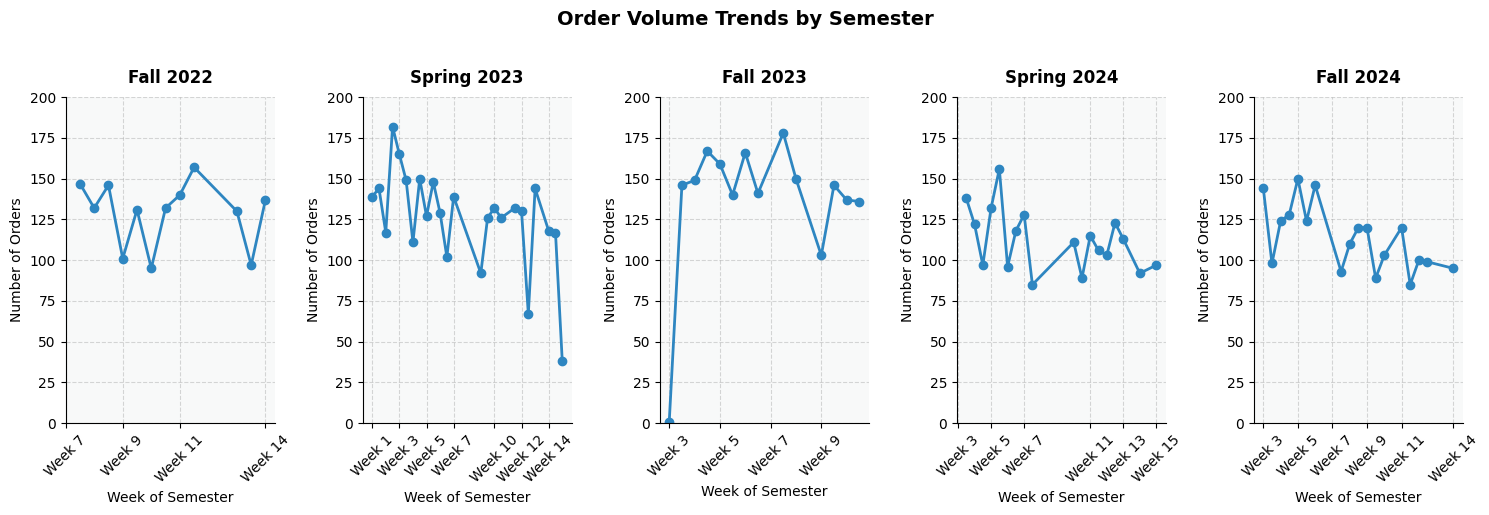

In [34]:
# create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()  # flatten to make indexing easier

plot_idx = 0

for semester_label in order:
    # parse year and semester from label
    sem, year = semester_label.split()
    year = int(year)
    
    # get data for this semester
    semester_data = df[
        (df["Year"] == year) & 
        (df["Semester"] == sem)
    ]
    
    if len(semester_data) > 0:
        # count orders per week-day combination
        weekly_orders = semester_data.groupby(["School_Week", "Weekday"]).size().reset_index()
        weekly_orders["Week_Offset"] = weekly_orders["School_Week"] + weekly_orders["Weekday"].map(offset_dict)
        weekly_orders.sort_values(by="Week_Offset", inplace=True)
        
        # plot with enhanced styling
        axes[plot_idx].plot(weekly_orders["Week_Offset"], weekly_orders[0], 
                          marker='o', 
                          linewidth=2, 
                          markersize=6,
                          color='#2E86C1')  # nice blue color
        
        # customize subplot
        axes[plot_idx].set_title(semester_label, pad=10, fontsize=12, fontweight='bold')
        axes[plot_idx].set_xlabel("Week of Semester", fontsize=10)
        axes[plot_idx].set_ylabel("Number of Orders", fontsize=10)
        axes[plot_idx].grid(True, linestyle='--', alpha=0.7)
        
        # customize ticks
        weeks = weekly_orders["School_Week"].unique()
        tick_weeks = weeks[::2]  # step by 2
        axes[plot_idx].set_xticks(tick_weeks)
        axes[plot_idx].set_xticklabels([f"Week {w}" for w in tick_weeks])
        axes[plot_idx].tick_params(axis='x', rotation=45)
        
        # add subtle background grid
        axes[plot_idx].set_facecolor('#F8F9F9')  # light gray background
        axes[plot_idx].grid(True, linestyle='--', alpha=0.3, color='gray')
        
        plot_idx += 1

# remove empty subplots
for idx in range(plot_idx, len(axes)):
    fig.delaxes(axes[idx])

# align y-axis limits
y_max = df.groupby(["Year", "Semester", "School_Week", "Weekday"]).size().max() * 1.1
for ax in axes[:plot_idx]:
    ax.set_ylim(0, y_max)
    ax.spines['top'].set_visible(False)  # remove top border
    ax.spines['right'].set_visible(False)  # remove right border

# add overall title
plt.suptitle('Order Volume Trends by Semester', 
             fontsize=14, 
             fontweight='bold', 
             y=1.02)

# adjust layout
plt.tight_layout()
plt.show()